# Binary Sentiment Classification: DistilBERT, CNN, and Hybrid Model Comparison

This notebook trains three models for binary sentiment classification on Amazon product reviews, compares their performance, and generates comprehensive evaluation metrics and visualizations.

## Section 0: Install Required Packages

In [1]:
!pip install -q transformers torch tensorflow scikit-learn pandas numpy matplotlib seaborn

## Section 1: Imports & Configuration

In [2]:
import os
import gc
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score, roc_auc_score, auc,
    roc_curve, precision_recall_curve, confusion_matrix, log_loss
)
import warnings
warnings.filterwarnings('ignore')

# TensorFlow and PyTorch
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")
print(f"CUDA available: {torch.cuda.is_available()}")

Using device: cuda
CUDA available: True


## Section 2: Data Loading & Preprocessing

In [4]:
# Load CSV
df = pd.read_csv('/content/Amazon_Reviews.csv', engine='python', on_bad_lines='warn')
print(f"Original dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(2))

Original dataset shape: (21214, 9)
Columns: ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']
      Reviewer Name                     Profile Link Country Review Count  \
0        Eugene ath  /users/66e8185ff1598352d6b3701a      US     1 review   
1  Daniel ohalloran  /users/5d75e460200c1f6a6373648c      GB    9 reviews   

                Review Date                  Rating  \
0  2024-09-16T13:44:26.000Z  Rated 1 out of 5 stars   
1  2024-09-16T18:26:46.000Z  Rated 1 out of 5 stars   

                                 Review Title  \
0  A Store That Doesn't Want to Sell Anything   
1      Had multiple orders one turned up and…   

                                         Review Text  Date of Experience  
0  I registered on the website, tried to order a ...  September 16, 2024  
1  Had multiple orders one turned up and driver h...  September 16, 2024  


In [5]:
# Extract numeric rating using regex
def extract_rating(rating_str):
    """Extract numeric rating from 'Rated X out of 5 stars' format."""
    if pd.isna(rating_str):
        return np.nan
    match = re.search(r'Rated\s+(\d+(?:\.\d+)?)\s+out of', str(rating_str))
    if match:
        return float(match.group(1))
    return np.nan

df['numeric_rating'] = df['Rating'].apply(extract_rating)
print(f"Rating distribution:\n{df['numeric_rating'].value_counts().sort_index()}")

Rating distribution:
numeric_rating
1.0    13123
2.0     1227
3.0      885
4.0     1292
5.0     4528
Name: count, dtype: int64


In [6]:
# Drop 3-star rows and map to binary labels
df = df[df['numeric_rating'] != 3.0].copy()
df['label'] = df['numeric_rating'].apply(lambda x: 0 if x < 3 else 1)

# Combine Review Title and Review Text
df['combined_text'] = df['Review Title'].fillna('') + ' ' + df['Review Text'].fillna('')
df['combined_text'] = df['combined_text'].str.strip()

# Remove rows with missing text
df = df[df['combined_text'].str.len() > 0].copy()

print(f"Final dataset shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"Class proportions:\n{df['label'].value_counts(normalize=True)}")

Final dataset shape: (20170, 12)
Label distribution:
label
0    14350
1     5820
Name: count, dtype: int64
Class proportions:
label
0    0.711453
1    0.288547
Name: proportion, dtype: float64


In [7]:
# Stratified train/val/test split (70/10/20)
X = df['combined_text'].values
y = df['label'].values

# First split: 70/30 (train / temp)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 33.33/66.67 of temp → 10/20 of total
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6667, random_state=SEED, stratify=y_temp
)

print(f"Train set: {len(X_train)} samples")
print(f"Val set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTrain label distribution: {np.bincount(y_train)}")
print(f"Val label distribution: {np.bincount(y_val)}")
print(f"Test label distribution: {np.bincount(y_test)}")

Train set: 14119 samples
Val set: 2016 samples
Test set: 4035 samples

Train label distribution: [10045  4074]
Val label distribution: [1434  582]
Test label distribution: [2871 1164]


In [16]:
# Compute class weights for imbalanced data
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: float(class_weights[i]) for i in range(len(class_weights))} # Convert np.float64 to native Python float
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 0.702787456445993, 1: 1.7328178694158076}


In [17]:
# Prepare CNN data with Keras Tokenizer
CNN_VOCAB_SIZE = 20000
CNN_MAX_LEN = 200

tokenizer_cnn = Tokenizer(num_words=CNN_VOCAB_SIZE, oov_token='<OOV>')
tokenizer_cnn.fit_on_texts(X_train)

X_train_cnn = pad_sequences(tokenizer_cnn.texts_to_sequences(X_train), maxlen=CNN_MAX_LEN, padding='post')
X_val_cnn = pad_sequences(tokenizer_cnn.texts_to_sequences(X_val), maxlen=CNN_MAX_LEN, padding='post')
X_test_cnn = pad_sequences(tokenizer_cnn.texts_to_sequences(X_test), maxlen=CNN_MAX_LEN, padding='post')

print(f"CNN sequences shape (train): {X_train_cnn.shape}")

CNN sequences shape (train): (14119, 200)


In [10]:
# Prepare DistilBERT data
DISTILBERT_MAX_LEN = 192

tokenizer_bert = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

def tokenize_texts(texts, tokenizer, max_length=192):
    """Tokenize texts for DistilBERT."""
    return tokenizer(
        texts.tolist() if isinstance(texts, np.ndarray) else texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors='pt'
    )

train_encodings = tokenize_texts(X_train, tokenizer_bert, DISTILBERT_MAX_LEN)
val_encodings = tokenize_texts(X_val, tokenizer_bert, DISTILBERT_MAX_LEN)
test_encodings = tokenize_texts(X_test, tokenizer_bert, DISTILBERT_MAX_LEN)

print(f"DistilBERT encodings (train): input_ids shape {train_encodings['input_ids'].shape}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

DistilBERT encodings (train): input_ids shape torch.Size([14119, 192])


## Section 3: CNN Model (Keras/TensorFlow)

In [23]:
def build_cnn_model(vocab_size, max_len, embedding_dim=128):
    """Build multi-kernel 1D CNN model."""
    inputs = layers.Input(shape=(max_len,))

    # Embedding
    x = layers.Embedding(vocab_size, embedding_dim)(inputs)

    # Three parallel Conv1D branches
    conv_branches = []
    for kernel_size in [2, 3, 4]:
        # Use padding='same' to ensure Conv1D output maintains sequence length
        conv = layers.Conv1D(128, kernel_size, activation='relu', padding='same')(x)
        # Removed BatchNormalization
        conv = layers.MaxPooling1D()(conv)
        conv_branches.append(conv)

    # Concatenate branches (now inputs will have matching sequence lengths)
    x = layers.Concatenate()(conv_branches)

    # Second Conv1D
    x = layers.Conv1D(64, 3, activation='relu')(x)
    x = layers.GlobalMaxPooling1D()(x)

    # Dense layers
    # Removed BatchNormalization
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    # Removed BatchNormalization
    x = layers.Dropout(0.3)(x)

    # Output
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

# Build CNN model
cnn_model = build_cnn_model(CNN_VOCAB_SIZE, CNN_MAX_LEN)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
    run_eagerly=True # Added to mitigate persistent graph execution errors
)
print("CNN Model Summary:")
cnn_model.summary()

CNN Model Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 200, 128)  │  2,560,000 │ input_layer_3[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 200, 128)  │     32,896 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 200, 128)  │     49,280 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 200, 128)  │     65,664 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_9     │ (None, 100, 128)  │          0 │ conv1d_11[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_10    │ (None, 100, 128)  │          0 │ conv1d_12[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_11    │ (None, 100, 128)  │          0 │ conv1d_13[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 100, 384)  │          0 │ max_pooling1d_9[… │
│ (Concatenate)       │                   │            │ max_pooling1d_10… │
│                     │                   │            │ max_pooling1d_11… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 98, 64)    │     73,792 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 64)        │          0 │ conv1d_14[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 64)        │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      8,320 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │        129 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,790,081 (10.64 MB)

 Trainable params: 2,790,081 (10.64 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Prepare class weights for Keras
# Create sample weights based on class_weight_dict for each training sample
sample_weight_train = np.array([class_weight_dict[label] for label in y_train])

# Explicitly cast y_train and y_val to float32 for binary_crossentropy compatibility
y_train_float = y_train.astype(np.float32)
y_val_float = y_val.astype(np.float32)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, min_lr=1e-7)

# Train CNN
print("Training CNN model...")
cnn_history = cnn_model.fit(
    X_train_cnn, y_train_float, # Use float labels
    validation_data=(X_val_cnn, y_val_float), # Use float labels
    # Removed sample_weight as it was causing an internal Keras/TensorFlow error
    epochs=15,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"CNN training completed. Best epoch: {len(cnn_history.history['loss']) - 4}")

Training CNN model...
Epoch 1/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 33s 125ms/step - accuracy: 0.8486 - loss: 0.3632 - val_accuracy: 0.9221 - val_loss: 0.2138 - learning_rate: 0.0010
Epoch 2/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 28s 125ms/step - accuracy: 0.9410 - loss: 0.1724 - val_accuracy: 0.9311 - val_loss: 0.1965 - learning_rate: 0.0010
Epoch 3/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 27s 124ms/step - accuracy: 0.9671 - loss: 0.1021 - val_accuracy: 0.9345 - val_loss: 0.2091 - learning_rate: 0.0010
Epoch 4/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step - accuracy: 0.9785 - loss: 0.0709 - val_accuracy: 0.9345 - val_loss: 0.2408 - learning_rate: 0.0010
Epoch 5/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - accuracy: 0.9877 - loss: 0.0398 - val_accuracy: 0.9325 - val_loss: 0.2709 - learning_rate: 5.0000e-04
Epoch 6/15
221/221 ━━━━━━━━━━━━━━━━━━━━ 27s 123ms/step - accuracy: 0.9943 - loss: 0.0230 - val_accuracy: 0.9320 - val_loss: 0.3003 - learning_rate: 5.0000e-04
CNN training completed. Best epoch: 2


In [25]:
# Predictions for CNN
cnn_train_preds = cnn_model.predict(X_train_cnn, verbose=0).flatten()
cnn_val_preds = cnn_model.predict(X_val_cnn, verbose=0).flatten()
cnn_test_preds = cnn_model.predict(X_test_cnn, verbose=0).flatten()

cnn_train_labels = (cnn_train_preds > 0.5).astype(int)
cnn_val_labels = (cnn_val_preds > 0.5).astype(int)
cnn_test_labels = (cnn_test_preds > 0.5).astype(int)

print(f"CNN test accuracy: {accuracy_score(y_test, cnn_test_labels):.4f}")

CNN test accuracy: 0.9257


## Section 4: DistilBERT Model (PyTorch)

In [26]:
class BertDataset(Dataset):
    """Custom dataset for DistilBERT."""
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Create datasets and dataloaders
train_dataset = BertDataset(train_encodings, y_train)
val_dataset = BertDataset(val_encodings, y_val)
test_dataset = BertDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=24, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=24)
test_loader = DataLoader(test_dataset, batch_size=24)

print(f"Train loader batches: {len(train_loader)}")
print(f"Val loader batches: {len(val_loader)}")
print(f"Test loader batches: {len(test_loader)}")

Train loader batches: 589
Val loader batches: 84
Test loader batches: 169


In [27]:
# Load pretrained DistilBERT
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
).to(DEVICE)

# Class weights for PyTorch
class_weights_tensor = torch.tensor([class_weight_dict[0], class_weight_dict[1]], dtype=torch.float).to(DEVICE)

# Loss function with class weights
criterion_bert = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer_bert = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

# Warmup scheduler
num_epochs_bert = 4
total_steps = len(train_loader) * num_epochs_bert
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print("DistilBERT model loaded and configured.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT model loaded and configured.


In [28]:
def train_epoch_bert(model, dataloader, optimizer, scheduler, criterion, device):
    """Train one epoch for DistilBERT."""
    model.train()
    total_loss = 0

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def validate_bert(model, dataloader, criterion, device):
    """Validate DistilBERT model."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1_macro = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, f1_macro, np.array(all_preds)

print("Training functions defined.")

Training functions defined.


In [29]:
# Train DistilBERT
print("Training DistilBERT model...")
bert_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1 = 0
best_model_path = '/tmp/best_bert_model.pt'

for epoch in range(num_epochs_bert):
    train_loss = train_epoch_bert(bert_model, train_loader, optimizer_bert, scheduler_bert, criterion_bert, DEVICE)
    val_loss, val_f1, _ = validate_bert(bert_model, val_loader, criterion_bert, DEVICE)

    bert_history['train_loss'].append(train_loss)
    bert_history['val_loss'].append(val_loss)
    bert_history['val_f1'].append(val_f1)

    print(f"Epoch {epoch+1}/{num_epochs_bert} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(bert_model.state_dict(), best_model_path)

# Load best checkpoint
bert_model.load_state_dict(torch.load(best_model_path))
print(f"Loaded best DistilBERT model with F1: {best_f1:.4f}")

Training DistilBERT model...
Epoch 1/4 - Train Loss: 0.2287, Val Loss: 0.1577, Val F1: 0.9348
Epoch 2/4 - Train Loss: 0.0778, Val Loss: 0.1102, Val F1: 0.9700
Epoch 3/4 - Train Loss: 0.0405, Val Loss: 0.1155, Val F1: 0.9719
Epoch 4/4 - Train Loss: 0.0226, Val Loss: 0.1219, Val F1: 0.9730
Loaded best DistilBERT model with F1: 0.9730


In [30]:
def get_predictions_bert(model, dataloader, device):
    """Get predictions and probabilities for DistilBERT."""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels']

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_probs.extend(probs[:, 1])  # Probability for positive class
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Get predictions
bert_train_labels, bert_train_preds, bert_train_probs = get_predictions_bert(bert_model, train_loader, DEVICE)
bert_val_labels, bert_val_preds, bert_val_probs = get_predictions_bert(bert_model, val_loader, DEVICE)
bert_test_labels, bert_test_preds, bert_test_probs = get_predictions_bert(bert_model, test_loader, DEVICE)

print(f"DistilBERT test accuracy: {accuracy_score(bert_test_labels, bert_test_preds):.4f}")

DistilBERT test accuracy: 0.9678


In [31]:
# Clean up
torch.cuda.empty_cache()
gc.collect()

75167

## Section 5: Hybrid DistilBERT + CNN Model (PyTorch)

In [32]:
class HybridBertCNNModel(nn.Module):
    """Hybrid DistilBERT + CNN model for sentiment classification."""
    def __init__(self, cnn_vocab_size, cnn_embedding_dim=128, distilbert_dim=768):
        super(HybridBertCNNModel, self).__init__()

        # DistilBERT branch (loaded separately)
        self.distilbert = DistilBertForSequenceClassification.from_pretrained(
            'distilbert-base-uncased', num_labels=2
        )

        # DistilBERT classification head
        self.bert_head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(distilbert_dim, 256),
            nn.ReLU()
        )

        # CNN branch (standalone)
        self.cnn_embedding = nn.Embedding(cnn_vocab_size, cnn_embedding_dim, padding_idx=0)

        self.conv_layers = nn.ModuleList([
            nn.Conv1d(cnn_embedding_dim, 128, kernel_size=k) for k in [2, 3, 4]
        ])

        self.cnn_head = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU()
        )

        # Fusion head
        self.fusion = nn.Sequential(
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, input_ids, attention_mask, cnn_input_ids):
        # DistilBERT branch
        bert_outputs = self.distilbert(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
        cls_hidden = bert_outputs.hidden_states[-1][:, 0, :]  # [CLS] token
        bert_feat = self.bert_head(cls_hidden)  # (batch, 256)

        # CNN branch
        cnn_emb = self.cnn_embedding(cnn_input_ids)  # (batch, seq_len, 128)
        cnn_emb = cnn_emb.transpose(1, 2)  # (batch, 128, seq_len)

        conv_outputs = []
        for conv in self.conv_layers:
            conv_out = torch.relu(conv(cnn_emb))  # (batch, 128, seq_len-kernel+1)
            pool_out = torch.max(conv_out, dim=2)[0]  # (batch, 128)
            conv_outputs.append(pool_out)

        cnn_concat = torch.cat(conv_outputs, dim=1)  # (batch, 384)
        cnn_feat = self.cnn_head(cnn_concat)  # (batch, 256)

        # Fusion
        fused = torch.cat([bert_feat, cnn_feat], dim=1)  # (batch, 512)
        logits = self.fusion(fused)  # (batch, 2)

        return logits

print("Hybrid model class defined.")

Hybrid model class defined.


In [33]:
class HybridDataset(Dataset):
    """Dataset for hybrid model with both BERT and CNN inputs."""
    def __init__(self, bert_encodings, cnn_sequences, labels):
        self.bert_encodings = bert_encodings
        self.cnn_sequences = cnn_sequences
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        bert_item = {key: val[idx] for key, val in self.bert_encodings.items()}
        bert_item['cnn_input_ids'] = torch.tensor(self.cnn_sequences[idx], dtype=torch.long)
        bert_item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return bert_item

# Create hybrid datasets and dataloaders
hybrid_train_dataset = HybridDataset(train_encodings, X_train_cnn, y_train)
hybrid_val_dataset = HybridDataset(val_encodings, X_val_cnn, y_val)
hybrid_test_dataset = HybridDataset(test_encodings, X_test_cnn, y_test)

hybrid_train_loader = DataLoader(hybrid_train_dataset, batch_size=24, shuffle=True)
hybrid_val_loader = DataLoader(hybrid_val_dataset, batch_size=24)
hybrid_test_loader = DataLoader(hybrid_test_dataset, batch_size=24)

print("Hybrid datasets and dataloaders created.")

Hybrid datasets and dataloaders created.


In [34]:
# Initialize hybrid model
hybrid_model = HybridBertCNNModel(cnn_vocab_size=CNN_VOCAB_SIZE).to(DEVICE)

print("Hybrid model initialized.")
print(f"Total parameters: {sum(p.numel() for p in hybrid_model.parameters()):,}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Hybrid model initialized.
Total parameters: 70,025,476


In [35]:
def train_epoch_hybrid(model, dataloader, optimizer, scheduler, criterion, device, freeze_bert=False):
    """Train one epoch for hybrid model."""
    model.train()
    total_loss = 0

    # Freeze/unfreeze DistilBERT encoder
    for param in model.distilbert.distilbert.parameters():
        param.requires_grad = not freeze_bert

    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        cnn_input_ids = batch['cnn_input_ids'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask, cnn_input_ids=cnn_input_ids)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def validate_hybrid(model, dataloader, criterion, device):
    """Validate hybrid model."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            cnn_input_ids = batch['cnn_input_ids'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask, cnn_input_ids=cnn_input_ids)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    f1_macro = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, f1_macro, np.array(all_preds)

print("Hybrid training functions defined.")

Hybrid training functions defined.


In [36]:
# Setup optimizer with differential learning rates
bert_params = list(hybrid_model.distilbert.parameters())
other_params = list(hybrid_model.bert_head.parameters()) + \
               list(hybrid_model.cnn_embedding.parameters()) + \
               list(hybrid_model.conv_layers.parameters()) + \
               list(hybrid_model.cnn_head.parameters()) + \
               list(hybrid_model.fusion.parameters())

optimizer_hybrid = optim.AdamW([
    {'params': bert_params, 'lr': 2e-5, 'weight_decay': 0.01},
    {'params': other_params, 'lr': 1e-3, 'weight_decay': 0.01}
])

criterion_hybrid = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Hybrid optimizer configured.")

Hybrid optimizer configured.


In [37]:
# Train hybrid model (freeze DistilBERT for first 2 epochs)
print("Training Hybrid model...")
hybrid_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1_hybrid = 0
best_model_hybrid_path = '/tmp/best_hybrid_model.pt'
num_epochs_hybrid = 4

for epoch in range(num_epochs_hybrid):
    freeze_encoder = epoch < 2  # Freeze for first 2 epochs

    # Create scheduler for this epoch only if first epoch
    if epoch == 0:
        total_steps_hybrid = len(hybrid_train_loader) * num_epochs_hybrid
        scheduler_hybrid = get_linear_schedule_with_warmup(
            optimizer_hybrid,
            num_warmup_steps=int(0.1 * total_steps_hybrid),
            num_training_steps=total_steps_hybrid
        )

    train_loss = train_epoch_hybrid(
        hybrid_model, hybrid_train_loader, optimizer_hybrid, scheduler_hybrid,
        criterion_hybrid, DEVICE, freeze_bert=freeze_encoder
    )
    val_loss, val_f1, _ = validate_hybrid(hybrid_model, hybrid_val_loader, criterion_hybrid, DEVICE)

    hybrid_history['train_loss'].append(train_loss)
    hybrid_history['val_loss'].append(val_loss)
    hybrid_history['val_f1'].append(val_f1)

    freeze_status = "(DistilBERT frozen)" if freeze_encoder else "(All unfrozen)"
    print(f"Epoch {epoch+1}/{num_epochs_hybrid} {freeze_status} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")

    if val_f1 > best_f1_hybrid:
        best_f1_hybrid = val_f1
        torch.save(hybrid_model.state_dict(), best_model_hybrid_path)

# Load best checkpoint
hybrid_model.load_state_dict(torch.load(best_model_hybrid_path))
print(f"Loaded best Hybrid model with F1: {best_f1_hybrid:.4f}")

Training Hybrid model...
Epoch 1/4 (DistilBERT frozen) - Train Loss: 0.2911, Val Loss: 0.1266, Val F1: 0.9508
Epoch 2/4 (DistilBERT frozen) - Train Loss: 0.1591, Val Loss: 0.1240, Val F1: 0.9634
Epoch 3/4 (All unfrozen) - Train Loss: 0.0798, Val Loss: 0.1454, Val F1: 0.9683
Epoch 4/4 (All unfrozen) - Train Loss: 0.0397, Val Loss: 0.1174, Val F1: 0.9740
Loaded best Hybrid model with F1: 0.9740


In [38]:
def get_predictions_hybrid(model, dataloader, device):
    """Get predictions and probabilities for hybrid model."""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            cnn_input_ids = batch['cnn_input_ids'].to(device)
            labels = batch['labels']

            logits = model(input_ids=input_ids, attention_mask=attention_mask, cnn_input_ids=cnn_input_ids)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)

            all_preds.extend(preds)
            all_probs.extend(probs[:, 1])  # Probability for positive class
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Get predictions
hybrid_train_labels, hybrid_train_preds, hybrid_train_probs = get_predictions_hybrid(hybrid_model, hybrid_train_loader, DEVICE)
hybrid_val_labels, hybrid_val_preds, hybrid_val_probs = get_predictions_hybrid(hybrid_model, hybrid_val_loader, DEVICE)
hybrid_test_labels, hybrid_test_preds, hybrid_test_probs = get_predictions_hybrid(hybrid_model, hybrid_test_loader, DEVICE)

print(f"Hybrid test accuracy: {accuracy_score(hybrid_test_labels, hybrid_test_preds):.4f}")

Hybrid test accuracy: 0.9668


In [39]:
# Clean up
torch.cuda.empty_cache()
gc.collect()

8

## Section 6: Evaluation & Metrics Computation

In [40]:
def compute_all_metrics(y_true, y_pred, y_pred_proba, model_name):
    """Compute all evaluation metrics for a model."""
    metrics = {}

    # Basic metrics
    metrics['Accuracy'] = accuracy_score(y_true, y_pred)

    # Precision, Recall, F1 (macro and weighted)
    metrics['Precision_Macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['Recall_Macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
    metrics['F1_Macro'] = f1_score(y_true, y_pred, average='macro', zero_division=0)

    metrics['Precision_Weighted'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['Recall_Weighted'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    metrics['F1_Weighted'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # Per-class metrics
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)

    metrics['Precision_Class0'] = precision_per_class[0]
    metrics['Precision_Class1'] = precision_per_class[1]
    metrics['Recall_Class0'] = recall_per_class[0]
    metrics['Recall_Class1'] = recall_per_class[1]

    # MCC and Cohen's Kappa
    metrics['MCC'] = matthews_corrcoef(y_true, y_pred)
    metrics['Cohen_Kappa'] = cohen_kappa_score(y_true, y_pred)

    # AUC-ROC
    metrics['AUC_ROC'] = roc_auc_score(y_true, y_pred_proba)

    # AUC-PR
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    metrics['AUC_PR'] = auc(recall_vals, precision_vals)

    # Specificity (TNR) - per class
    cm = confusion_matrix(y_true, y_pred)
    tn_class0 = cm[1, 1]
    fp_class0 = cm[0, 1]
    specificity_class0 = tn_class0 / (tn_class0 + fp_class0) if (tn_class0 + fp_class0) > 0 else 0

    tn_class1 = cm[0, 0]
    fp_class1 = cm[1, 0]
    specificity_class1 = tn_class1 / (tn_class1 + fp_class1) if (tn_class1 + fp_class1) > 0 else 0

    metrics['Specificity_Class0'] = specificity_class0
    metrics['Specificity_Class1'] = specificity_class1

    # Log loss
    metrics['Log_Loss'] = log_loss(y_true, y_pred_proba)

    # Store confusion matrix
    metrics['Confusion_Matrix'] = cm
    metrics['ROC_Curve'] = roc_curve(y_true, y_pred_proba)
    metrics['PR_Curve'] = (recall_vals, precision_vals)

    return metrics

print("Metrics computation function defined.")

Metrics computation function defined.


In [41]:
# Compute metrics for all three models on test set
cnn_metrics = compute_all_metrics(y_test, cnn_test_labels, cnn_test_preds, 'CNN')
bert_metrics = compute_all_metrics(bert_test_labels, bert_test_preds, bert_test_probs, 'DistilBERT')
hybrid_metrics = compute_all_metrics(hybrid_test_labels, hybrid_test_preds, hybrid_test_probs, 'Hybrid')

print("Metrics computed for all models on test set.")

Metrics computed for all models on test set.


In [42]:
# Create consolidated results table
results_dict = {
    'Model': ['CNN', 'DistilBERT', 'Hybrid'],
    'Accuracy': [
        cnn_metrics['Accuracy'],
        bert_metrics['Accuracy'],
        hybrid_metrics['Accuracy']
    ],
    'Precision_Macro': [
        cnn_metrics['Precision_Macro'],
        bert_metrics['Precision_Macro'],
        hybrid_metrics['Precision_Macro']
    ],
    'Recall_Macro': [
        cnn_metrics['Recall_Macro'],
        bert_metrics['Recall_Macro'],
        hybrid_metrics['Recall_Macro']
    ],
    'F1_Macro': [
        cnn_metrics['F1_Macro'],
        bert_metrics['F1_Macro'],
        hybrid_metrics['F1_Macro']
    ],
    'Precision_Weighted': [
        cnn_metrics['Precision_Weighted'],
        bert_metrics['Precision_Weighted'],
        hybrid_metrics['Precision_Weighted']
    ],
    'Recall_Weighted': [
        cnn_metrics['Recall_Weighted'],
        bert_metrics['Recall_Weighted'],
        hybrid_metrics['Recall_Weighted']
    ],
    'F1_Weighted': [
        cnn_metrics['F1_Weighted'],
        bert_metrics['F1_Weighted'],
        hybrid_metrics['F1_Weighted']
    ],
    'MCC': [
        cnn_metrics['MCC'],
        bert_metrics['MCC'],
        hybrid_metrics['MCC']
    ],
    'Cohen_Kappa': [
        cnn_metrics['Cohen_Kappa'],
        bert_metrics['Cohen_Kappa'],
        hybrid_metrics['Cohen_Kappa']
    ],
    'AUC_ROC': [
        cnn_metrics['AUC_ROC'],
        bert_metrics['AUC_ROC'],
        hybrid_metrics['AUC_ROC']
    ],
    'AUC_PR': [
        cnn_metrics['AUC_PR'],
        bert_metrics['AUC_PR'],
        hybrid_metrics['AUC_PR']
    ],
    'Specificity_Class0': [
        cnn_metrics['Specificity_Class0'],
        bert_metrics['Specificity_Class0'],
        hybrid_metrics['Specificity_Class0']
    ],
    'Specificity_Class1': [
        cnn_metrics['Specificity_Class1'],
        bert_metrics['Specificity_Class1'],
        hybrid_metrics['Specificity_Class1']
    ],
    'Log_Loss': [
        cnn_metrics['Log_Loss'],
        bert_metrics['Log_Loss'],
        hybrid_metrics['Log_Loss']
    ]
}

results_df = pd.DataFrame(results_dict)

# Round to 4 decimal places
for col in results_df.columns[1:]:
    results_df[col] = results_df[col].round(4)

print("\n" + "="*120)
print("CONSOLIDATED RESULTS TABLE (Test Set)")
print("="*120)
print(results_df.to_string(index=False))
print("="*120)


CONSOLIDATED RESULTS TABLE (Test Set)
     Model  Accuracy  Precision_Macro  Recall_Macro  F1_Macro  Precision_Weighted  Recall_Weighted  F1_Weighted    MCC  Cohen_Kappa  AUC_ROC  AUC_PR  Specificity_Class0  Specificity_Class1  Log_Loss
       CNN    0.9257           0.9247        0.8913    0.9059              0.9255           0.9257       0.9241 0.8153       0.8121   0.9651  0.9390              0.9227              0.9267    0.2230
DistilBERT    0.9678           0.9614        0.9600    0.9607              0.9677           0.9678       0.9678 0.9214       0.9214   0.9887  0.9805              0.9465              0.9764    0.1609
    Hybrid    0.9668           0.9615        0.9573    0.9594              0.9667           0.9668       0.9667 0.9188       0.9187   0.9815  0.9745              0.9494              0.9737    0.1579


In [43]:
# Save results to CSV
results_df.to_csv('/content/metrics_table_ieee.csv', index=False)
print("Results table saved to /content/metrics_table_ieee.csv")

Results table saved to /content/metrics_table_ieee.csv


## Section 7: Visualizations

Comparison figure saved to /content/model_comparison_ieee.png


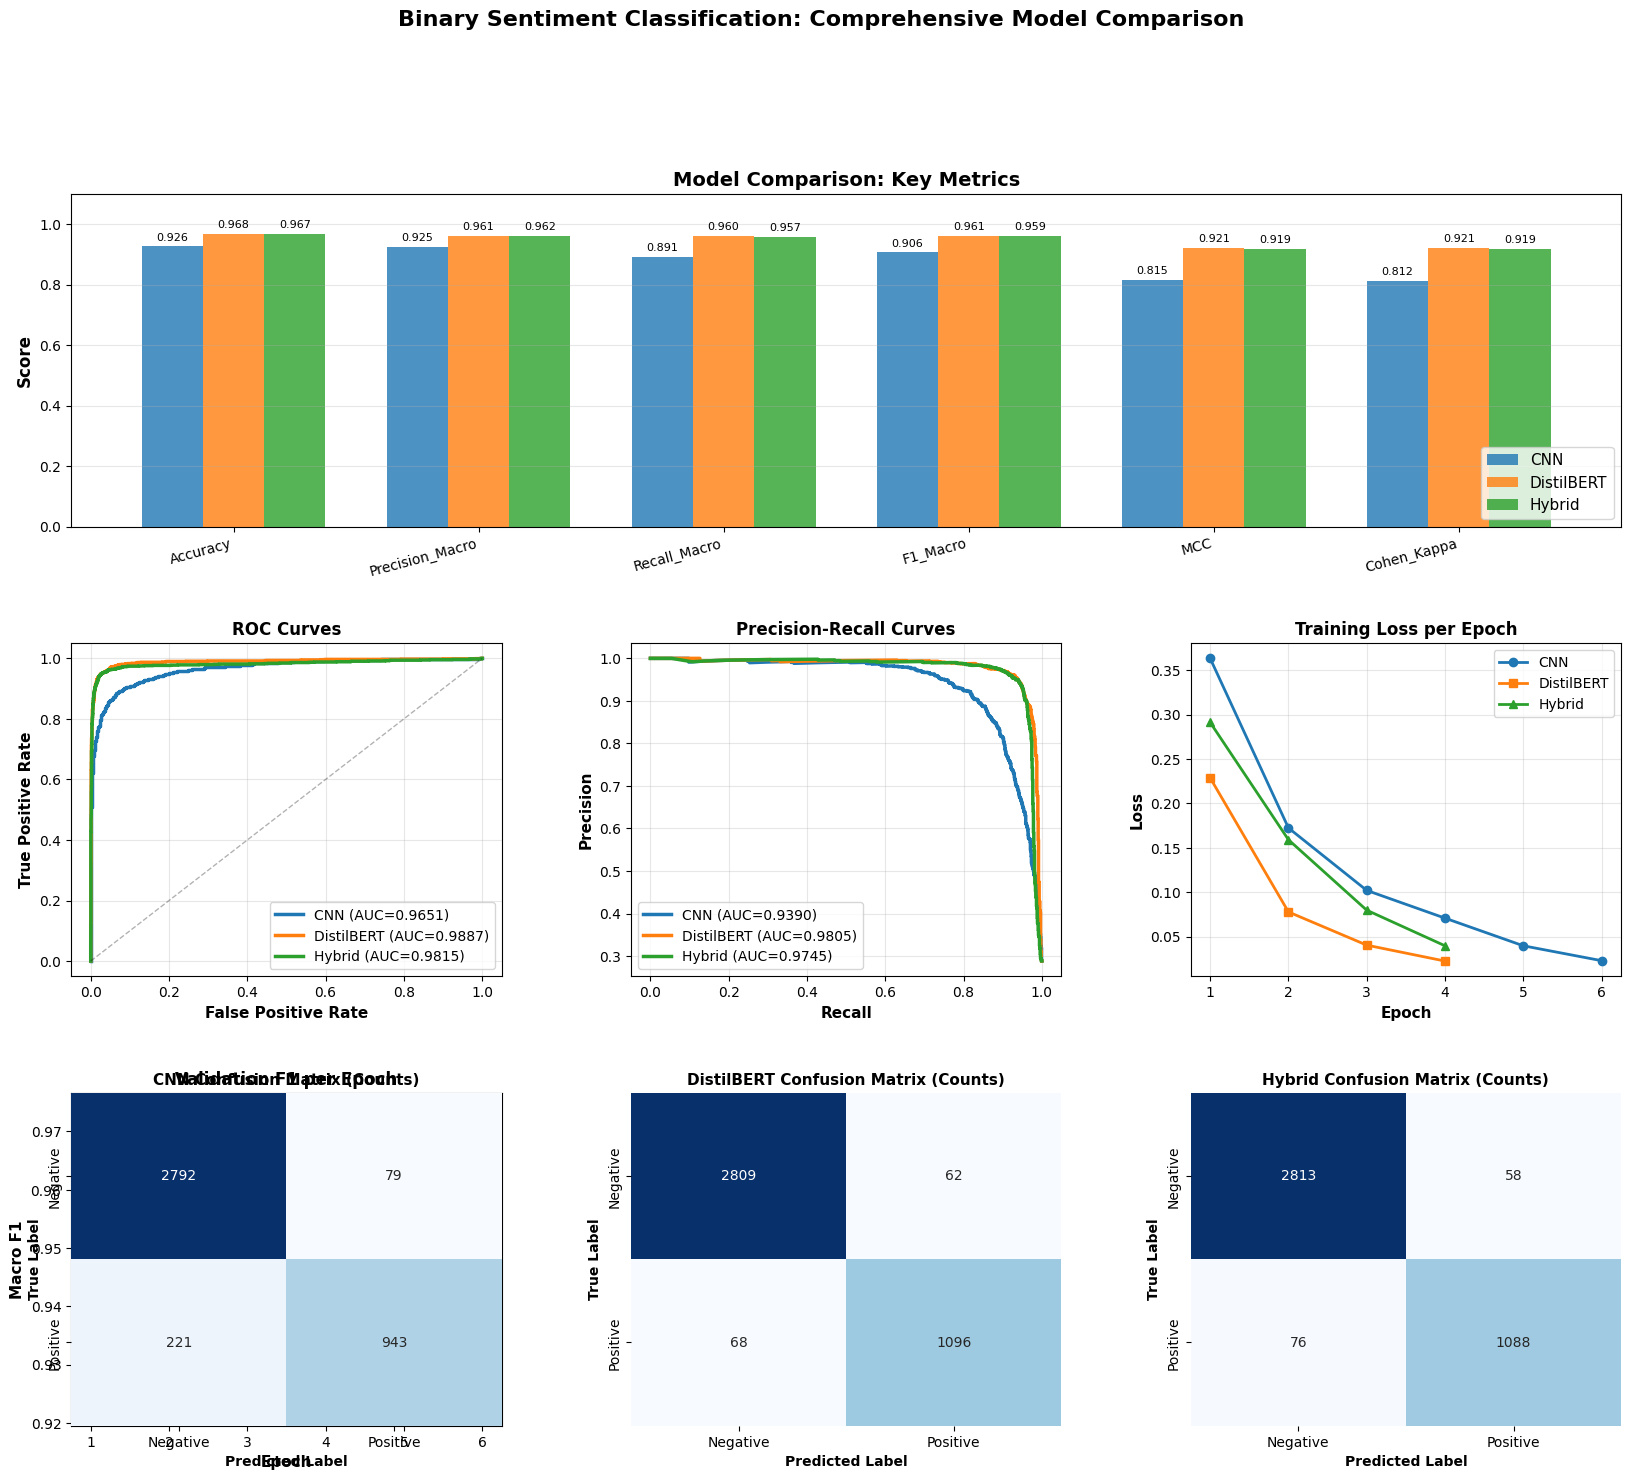

In [44]:
# Create comprehensive comparison figure
fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Color palette for models
colors = {'CNN': '#1f77b4', 'DistilBERT': '#ff7f0e', 'Hybrid': '#2ca02c'}
model_names = ['CNN', 'DistilBERT', 'Hybrid']

# ========== Subplot 1: Grouped Bar Chart ==========
ax1 = fig.add_subplot(gs[0, :])

metrics_to_plot = ['Accuracy', 'Precision_Macro', 'Recall_Macro', 'F1_Macro', 'MCC', 'Cohen_Kappa']
x = np.arange(len(metrics_to_plot))
width = 0.25

cnn_vals = [cnn_metrics[m] for m in metrics_to_plot]
bert_vals = [bert_metrics[m] for m in metrics_to_plot]
hybrid_vals = [hybrid_metrics[m] for m in metrics_to_plot]

rects1 = ax1.bar(x - width, cnn_vals, width, label='CNN', color=colors['CNN'], alpha=0.8)
rects2 = ax1.bar(x, bert_vals, width, label='DistilBERT', color=colors['DistilBERT'], alpha=0.8)
rects3 = ax1.bar(x + width, hybrid_vals, width, label='Hybrid', color=colors['Hybrid'], alpha=0.8)

# Annotate bars
for rects in [rects1, rects2, rects3]:
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=8)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Comparison: Key Metrics', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_to_plot, rotation=15, ha='right')
ax1.legend(loc='lower right', fontsize=11)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, 1.1])

# ========== Subplot 2: ROC Curves ==========
ax2 = fig.add_subplot(gs[1, 0])

fpr_cnn, tpr_cnn, _ = cnn_metrics['ROC_Curve']
fpr_bert, tpr_bert, _ = bert_metrics['ROC_Curve']
fpr_hybrid, tpr_hybrid, _ = hybrid_metrics['ROC_Curve']

ax2.plot(fpr_cnn, tpr_cnn, label=f"CNN (AUC={cnn_metrics['AUC_ROC']:.4f})", color=colors['CNN'], linewidth=2.5)
ax2.plot(fpr_bert, tpr_bert, label=f"DistilBERT (AUC={bert_metrics['AUC_ROC']:.4f})", color=colors['DistilBERT'], linewidth=2.5)
ax2.plot(fpr_hybrid, tpr_hybrid, label=f"Hybrid (AUC={hybrid_metrics['AUC_ROC']:.4f})", color=colors['Hybrid'], linewidth=2.5)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1)

ax2.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax2.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax2.set_title('ROC Curves', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(alpha=0.3)

# ========== Subplot 3: Precision-Recall Curves ==========
ax3 = fig.add_subplot(gs[1, 1])

recall_cnn, precision_cnn = cnn_metrics['PR_Curve']
recall_bert, precision_bert = bert_metrics['PR_Curve']
recall_hybrid, precision_hybrid = hybrid_metrics['PR_Curve']

ax3.plot(recall_cnn, precision_cnn, label=f"CNN (AUC={cnn_metrics['AUC_PR']:.4f})", color=colors['CNN'], linewidth=2.5)
ax3.plot(recall_bert, precision_bert, label=f"DistilBERT (AUC={bert_metrics['AUC_PR']:.4f})", color=colors['DistilBERT'], linewidth=2.5)
ax3.plot(recall_hybrid, precision_hybrid, label=f"Hybrid (AUC={hybrid_metrics['AUC_PR']:.4f})", color=colors['Hybrid'], linewidth=2.5)

ax3.set_xlabel('Recall', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision', fontsize=11, fontweight='bold')
ax3.set_title('Precision-Recall Curves', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(alpha=0.3)

# ========== Subplot 4: Training Loss Curves ==========
ax4 = fig.add_subplot(gs[1, 2])

epochs_cnn = range(1, len(cnn_history.history['loss']) + 1)
epochs_bert = range(1, len(bert_history['train_loss']) + 1)
epochs_hybrid = range(1, len(hybrid_history['train_loss']) + 1)

ax4.plot(epochs_cnn, cnn_history.history['loss'], marker='o', label='CNN', color=colors['CNN'], linewidth=2)
ax4.plot(epochs_bert, bert_history['train_loss'], marker='s', label='DistilBERT', color=colors['DistilBERT'], linewidth=2)
ax4.plot(epochs_hybrid, hybrid_history['train_loss'], marker='^', label='Hybrid', color=colors['Hybrid'], linewidth=2)

ax4.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax4.set_ylabel('Loss', fontsize=11, fontweight='bold')
ax4.set_title('Training Loss per Epoch', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=10)
ax4.grid(alpha=0.3)

# ========== Subplot 5: Validation F1 Curves ==========
ax5 = fig.add_subplot(gs[2, 0])

ax5.plot(epochs_cnn, cnn_history.history['val_accuracy'], marker='o', label='CNN', color=colors['CNN'], linewidth=2)  # Using val_accuracy proxy
ax5.plot(epochs_bert, bert_history['val_f1'], marker='s', label='DistilBERT', color=colors['DistilBERT'], linewidth=2)
ax5.plot(epochs_hybrid, hybrid_history['val_f1'], marker='^', label='Hybrid', color=colors['Hybrid'], linewidth=2)

ax5.set_xlabel('Epoch', fontsize=11, fontweight='bold')
ax5.set_ylabel('Macro F1', fontsize=11, fontweight='bold')
ax5.set_title('Validation F1 per Epoch', fontsize=12, fontweight='bold')
ax5.legend(loc='best', fontsize=10)
ax5.grid(alpha=0.3)

# ========== Subplots 6-8: Confusion Matrices ==========
for idx, (cm, model_name) in enumerate([
    (cnn_metrics['Confusion_Matrix'], 'CNN'),
    (bert_metrics['Confusion_Matrix'], 'DistilBERT'),
    (hybrid_metrics['Confusion_Matrix'], 'Hybrid')
]):
    ax = fig.add_subplot(gs[2, idx])

    # Absolute counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])

    ax.set_ylabel('True Label', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold')
    ax.set_title(f'{model_name} Confusion Matrix (Counts)', fontsize=11, fontweight='bold')

plt.suptitle('Binary Sentiment Classification: Comprehensive Model Comparison',
             fontsize=16, fontweight='bold', y=0.995)

plt.savefig('/content/model_comparison_ieee.png', dpi=300, bbox_inches='tight')
print("Comparison figure saved to /content/model_comparison_ieee.png")
plt.show()

In [45]:
# Print confusion matrices in normalized form
print("\n" + "="*100)
print("CONFUSION MATRICES (Normalized - Row-wise)")
print("="*100)

for cm, model_name in [
    (cnn_metrics['Confusion_Matrix'], 'CNN'),
    (bert_metrics['Confusion_Matrix'], 'DistilBERT'),
    (hybrid_metrics['Confusion_Matrix'], 'Hybrid')
]:
    print(f"\n{model_name}:")
    print("Absolute Counts:")
    print(cm)

    # Normalize row-wise
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print("\nNormalized (Row-wise):")
    print(cm_norm.round(4))


CONFUSION MATRICES (Normalized - Row-wise)

CNN:
Absolute Counts:
[[2792   79]
 [ 221  943]]

Normalized (Row-wise):
[[0.9725 0.0275]
 [0.1899 0.8101]]

DistilBERT:
Absolute Counts:
[[2809   62]
 [  68 1096]]

Normalized (Row-wise):
[[0.9784 0.0216]
 [0.0584 0.9416]]

Hybrid:
Absolute Counts:
[[2813   58]
 [  76 1088]]

Normalized (Row-wise):
[[0.9798 0.0202]
 [0.0653 0.9347]]


In [46]:
# Print per-class metrics summary
print("\n" + "="*100)
print("PER-CLASS METRICS SUMMARY")
print("="*100)

per_class_data = {
    'Metric': ['Precision', 'Recall', 'Specificity', 'F1'],
    'CNN_Class0': [
        cnn_metrics['Precision_Class0'],
        cnn_metrics['Recall_Class0'],
        cnn_metrics['Specificity_Class0'],
        f1_score(y_test == 0, cnn_test_labels == 0)
    ],
    'CNN_Class1': [
        cnn_metrics['Precision_Class1'],
        cnn_metrics['Recall_Class1'],
        cnn_metrics['Specificity_Class1'],
        f1_score(y_test == 1, cnn_test_labels == 1)
    ],
    'DistilBERT_Class0': [
        bert_metrics['Precision_Class0'],
        bert_metrics['Recall_Class0'],
        bert_metrics['Specificity_Class0'],
        f1_score(y_test == 0, bert_test_preds == 0)
    ],
    'DistilBERT_Class1': [
        bert_metrics['Precision_Class1'],
        bert_metrics['Recall_Class1'],
        bert_metrics['Specificity_Class1'],
        f1_score(y_test == 1, bert_test_preds == 1)
    ],
    'Hybrid_Class0': [
        hybrid_metrics['Precision_Class0'],
        hybrid_metrics['Recall_Class0'],
        hybrid_metrics['Specificity_Class0'],
        f1_score(y_test == 0, hybrid_test_preds == 0)
    ],
    'Hybrid_Class1': [
        hybrid_metrics['Precision_Class1'],
        hybrid_metrics['Recall_Class1'],
        hybrid_metrics['Specificity_Class1'],
        f1_score(y_test == 1, hybrid_test_preds == 1)
    ]
}

per_class_df = pd.DataFrame(per_class_data)
for col in per_class_df.columns[1:]:
    per_class_df[col] = per_class_df[col].round(4)

print(per_class_df.to_string(index=False))


PER-CLASS METRICS SUMMARY
     Metric  CNN_Class0  CNN_Class1  DistilBERT_Class0  DistilBERT_Class1  Hybrid_Class0  Hybrid_Class1
  Precision      0.9267      0.9227             0.9764             0.9465         0.9737         0.9494
     Recall      0.9725      0.8101             0.9784             0.9416         0.9798         0.9347
Specificity      0.9227      0.9267             0.9465             0.9764         0.9494         0.9737
         F1      0.9490      0.8628             0.9774             0.9440         0.9767         0.9420


In [47]:
print("\n" + "="*100)
print("NOTEBOOK EXECUTION COMPLETE")
print("="*100)
print(f"\nResults Summary:")
print(f"  - Test set size: {len(y_test)} samples")
print(f"  - Models trained and evaluated: CNN, DistilBERT, Hybrid")
print(f"  - All three models trained on identical 70/10/20 stratified splits")
print(f"\nOutput Files:")
print(f"  - Metrics table: /content/metrics_table_ieee.csv")
print(f"  - Comparison figure: /content/model_comparison_ieee.png")
print(f"\nKey Findings:")
best_model = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"  - Best model by accuracy: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"  - Best model by F1 (Macro): {results_df.loc[results_df['F1_Macro'].idxmax(), 'Model']} ({results_df.loc[results_df['F1_Macro'].idxmax(), 'F1_Macro']:.4f})")
print(f"  - Best model by AUC-ROC: {results_df.loc[results_df['AUC_ROC'].idxmax(), 'Model']} ({results_df.loc[results_df['AUC_ROC'].idxmax(), 'AUC_ROC']:.4f})")
print("="*100)


NOTEBOOK EXECUTION COMPLETE

Results Summary:
  - Test set size: 4035 samples
  - Models trained and evaluated: CNN, DistilBERT, Hybrid
  - All three models trained on identical 70/10/20 stratified splits

Output Files:
  - Metrics table: /content/metrics_table_ieee.csv
  - Comparison figure: /content/model_comparison_ieee.png

Key Findings:
  - Best model by accuracy: DistilBERT (0.9678)
  - Best model by F1 (Macro): DistilBERT (0.9607)
  - Best model by AUC-ROC: DistilBERT (0.9887)
